In [1]:
from skyfield.api import load
import numpy as np
import matplotlib.pyplot as plt
from skyfield.api import load, wgs84

# 单史料计算ΔT

“六年十二月戊午朔，日有蚀之，几尽，地如昏状。在须女十一度，女主恶之。后二岁三月，邓太后崩。”——《后汉书第十八》

In [2]:
input_y = 120
input_m = 1
input_d = 18


In [3]:
def calendar_to_jd(year, month, day, calendar_type="julian"):
    """将指定的历法日期转换为连续的儒略日 (JD)

    注意：天文纪年中，公元前708年对应的年份数字是 -707。
    """
    if month <= 2:
        year -= 1
        month += 12

    A = int(year / 100)

    # 根据不同的输入历法计算世纪修正值 B
    if calendar_type.lower() == "gregorian":
        B = 2 - A + int(A / 4)
    else:  # julian 历法（公元前708年选用此项）
        B = 0

    # 经典 Meeus 儒略日计算公式
    jd = (
        int(365.25 * (year + 4716))
        + int(30.6001 * (month + 1))
        + day
        + B
        - 1524.5
    )
    return jd


def jd_to_calendar(jd, to_calendar="gregorian"):
    """将中转的儒略日 (JD) 准确转换回目标历法日期"""
    jd += 0.5
    Z = int(jd)
    F = jd - Z

    if to_calendar.lower() == "gregorian":
        alpha = int((Z - 1867216.25) / 36524.25)
        A = Z + 1 + alpha - int(alpha / 4)
    else:  # 转换为儒略历
        A = Z

    B = A + 1524
    C = int((B - 122.1) / 365.25)
    D = int(365.25 * C)
    E = int((B - D) / 30.6001)

    day = B - D - int(30.6001 * E) + F
    if E < 14:
        month = E - 1
    else:
        month = E - 13

    if month > 2:
        year = C - 4716
    else:
        year = C - 4715

    return int(year), int(month), int(day)


def julian_to_gregorian_preset(year, month, day):
    """主转换核心函数：儒略历 转 格里高利历"""
    # 1. 先将输入的儒略历转换为绝对儒略日(JD)
    jd_mid = calendar_to_jd(year, month, day, calendar_type="julian")

    # 2. 再将这个 JD 转换回外推的格里高利历日期
    g_year, g_month, g_day = jd_to_calendar(jd_mid, to_calendar="gregorian")

    return g_year, g_month, g_day


if __name__ == "__main__":
    year, month, day = julian_to_gregorian_preset(input_y, input_m, input_d)

    print(f"【输入测试】儒略历: {input_y}年{input_m}月{input_d}日")
    print(f"【结果输出】格里高利历: {year}年{month}月{day}日")

【输入测试】儒略历: 120年1月18日
【结果输出】格里高利历: 120年1月17日


tt_best: <Time tt=1764904.836111111>
(120, 1, 17, 8, 4, 1.0913936421275139e-11)
min_sep: 0.7667858622610896
视直径比例 (月/日): 1.02352385195657 (大于1表示月亮更大，具备全食条件)
dt_theo:9204.463191531437
1764904.6666666667


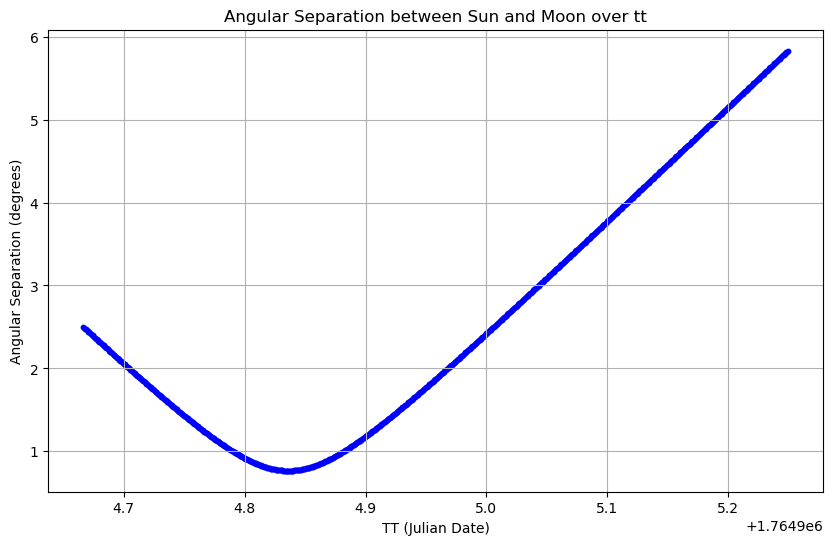

In [4]:
# 1. TT时下的可能最佳日食时间

# 1.1 加载数据
eph = load('de441.bsp')
sun, moon, earth = eph['sun'], eph['moon'], eph['earth']
ts = load.timescale()

# 1.2 已知公元历下的年月日(UT)
t_year = year 
t_month = month
t_day = day 
hour_min = 4
hour_max = 18
# 1.2.2 可能范围
hours = np.arange(hour_min, hour_max)
minutes = np.arange(0, 60)
h_mesh, m_mesh = np.meshgrid(hours, minutes) # 生成小时和分钟的网格,使得后面tt的范围形状一致


# 1.3 转化为TT时,假设与UT时在同一天(ΔT不会差到十几二十个小时...),通过日月地距离规范日全食时间
tt_min = ts.tt(t_year, t_month, t_day, hour_min)
tt_max = ts.tt(t_year, t_month, t_day, hour_max)
tt_steps = ts.tt(t_year, t_month, t_day, h_mesh.flatten(), m_mesh.flatten())

# 1.4 计算太阳、月亮在日心坐标系下的几何位置，日月地心重合时候即为日食
# 1.4.1 输出不同时刻日地、月地相对位置关系
astrometric_sun = earth.at(tt_steps).observe(sun)
astrometric_moon = earth.at(tt_steps).observe(moon) 
# 1.4.2 日心、地心、月心在一条直线上时，即日月角距离最小
separation = astrometric_sun.separation_from(astrometric_moon) # 角距离
index = np.argmin(separation.arcseconds())# 角距离最小时候的索引
tt_best = tt_steps[index] # 最合适的TT
min_sep = separation.degrees[index] # 最小角距离
print(f"tt_best: {tt_best}")
print(tt_best.tt_calendar())
print(f"min_sep: {min_sep}")
# 1.4.3 验证此时地球视角下月亮比太阳大
dist_sun = astrometric_sun[index].distance().au # 日地距离
dist_moon = astrometric_moon[index].distance().au  # 月地距离
# 视直径对比：月球距离/太阳距离 如果小于 月球半径/太阳半径，则可能发生全食
ratio = (3474 / dist_moon) / (1392700 / dist_sun)
print(f"视直径比例 (月/日): {ratio} (大于1表示月亮更大，具备全食条件)")

# 1.5 理论ΔT
dt_best_theo = tt_best.delta_t
print(f"dt_theo:{tt_best.delta_t}")
print(tt_steps.tt[0])
# 1.6 对角距离关系进行绘图
plt.figure(figsize=(10, 6))
plt.title("Angular Separation between Sun and Moon over tt")
plt.xlabel("TT (Julian Date)")
plt.ylabel("Angular Separation (degrees)")
plt.grid()
plt.scatter(tt_steps.tt, separation.degrees, s=10, color='blue', label='Angular Separation')